# Análise de NPS - E-commerce

## Objetivo

Este projeto tem como objetivo analisar os fatores que influenciam a satisfação dos clientes em um e-commerce, utilizando indicadores operacionais relacionados à logística, atendimento e comportamento de compra.

Ao longo da análise serão realizadas:

- preparação e tratamento dos dados;
- análise exploratória (EDA);
- identificação dos fatores que mais impactam o NPS;
- geração de insights para apoiar decisões de negócio.

# Por que o NPS é importante para um e-commerce?

O NPS é uma das métricas mais utilizadas para medir a satisfação e a lealdade dos clientes. Além de indicar o nível de satisfação após uma compra, ele permite avaliar a probabilidade de o cliente recomendar a empresa para outras pessoas.

Para um e-commerce, acompanhar o NPS é fundamental porque clientes satisfeitos tendem a comprar novamente, gerar avaliações positivas e fortalecer a reputação da marca. Já clientes insatisfeitos podem deixar de comprar, realizar reclamações e compartilhar experiências negativas.

# Quais áreas poderiam se beneficiar desses insights?

Os resultados desta análise podem apoiar diferentes áreas da empresa:

**Logística:** identificar problemas relacionados ao prazo de entrega, atrasos e tentativas de entrega.
**Atendimento ao Cliente:** reduzir o número de contatos necessários para resolver problemas e melhorar a qualidade do suporte.
**Operações:** otimizar processos internos para diminuir o tempo de resolução de ocorrências.
**Pricing e Comercial:** avaliar se políticas de descontos ou formas de pagamento influenciam a satisfação dos clientes.
**Gestão:** utilizar os indicadores para priorizar investimentos e definir estratégias de melhoria contínua.

# Como o NPS impacta o negócio?

**# Recompra**

Clientes com maior satisfação possuem maior probabilidade de realizar novas compras, aumentando a retenção e reduzindo os custos de aquisição de novos clientes. Essa relação também foi observada na análise exploratória, em que a variável de recompra apresentou forte correlação positiva com o NPS.

**# Boca a boca**

Clientes promotores tendem a recomendar espontaneamente a empresa para amigos e familiares, fortalecendo a reputação da marca e contribuindo para a aquisição de novos consumidores de forma orgânica. Em contrapartida, detratores podem compartilhar experiências negativas, prejudicando a imagem da empresa.

**# Market Share**

Empresas que mantêm elevados níveis de satisfação costumam apresentar maior fidelização e crescimento sustentável, o que pode resultar em aumento da participação de mercado. Já baixos índices de satisfação podem favorecer a migração dos clientes para concorrentes.

# Além do NPS, outros indicadores podem fornecer uma visão mais completa do desempenho da empresa:

Taxa de recompra;
Taxa de retenção de clientes;
Customer Satisfaction Score (CSAT);
Customer Effort Score (CES);
SLA logístico (tempo de entrega e percentual de entregas no prazo);
Tempo médio de atendimento e resolução;
Taxa de reclamações;
Benchmark de NPS do setor;
Comparação com indicadores de concorrentes;
Lifetime Value (LTV) e Churn Rate.

# Qual variável representa a satisfação do cliente?

A variável que representa a satisfação do cliente é nps_score.

# Por que ela foi escolhida?

O NPS foi escolhido porque é um indicador amplamente utilizado para medir a percepção do cliente em relação à empresa. A partir da nota atribuída pelo consumidor, é possível classificá-lo como Promotor, Neutro ou Detrator, permitindo avaliar o nível de satisfação e lealdade.

Além disso, o NPS apresenta forte relação com indicadores importantes para o negócio, como retenção de clientes, recompra e recomendação da marca.

# Em que momento da jornada essa informação é coletada?

O NPS normalmente é coletado após a conclusão da compra e da entrega do produto, quando o cliente já vivenciou toda a experiência de compra, incluindo pagamento, logística, recebimento do pedido e, quando necessário, atendimento ao cliente.

Dessa forma, a nota reflete a percepção geral da experiência oferecida pelo e-commerce.

# Existe algum risco de utilizar essa variável de forma inadequada?

Sim. Embora o NPS seja um excelente indicador de satisfação, ele não identifica sozinho a causa da insatisfação dos clientes.

Utilizar apenas essa métrica pode levar a interpretações equivocadas, pois uma nota baixa pode ser consequência de diferentes fatores, como atrasos na entrega, problemas com o produto, dificuldades no atendimento ou questões externas à empresa.

Por isso, o NPS deve ser analisado em conjunto com outras variáveis operacionais e indicadores de desempenho, permitindo identificar as causas reais da satisfação ou insatisfação e direcionar ações de melhoria de forma mais assertiva.

Importação das bibliotecas


In [1]:
import pandas as pd
import numpy as np


pd.set_option('display.max_colwidth', None)
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração dos gráficos
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (10,6)

# Exibir todas as colunas
pd.set_option('display.max_columns', None)

Leitura da base

In [2]:
df = pd.read_csv("../data/desafio_nps_fase_1.csv")

df.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


Quantidade de linhas e colunas

In [3]:
print(f'Linhas: {df.shape[0]}')
print(f'Colunas: {df.shape[1]}')

Linhas: 2500
Colunas: 19


Tipos das variáveis

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                2500 non-null   int64  
 1   customer_age               2500 non-null   int64  
 2   customer_region            2500 non-null   str    
 3   customer_tenure_months     2500 non-null   int64  
 4   order_id                   2500 non-null   int64  
 5   order_value                2500 non-null   float64
 6   items_quantity             2500 non-null   int64  
 7   discount_value             2500 non-null   float64
 8   payment_installments       2500 non-null   int64  
 9   delivery_time_days         2500 non-null   int64  
 10  delivery_delay_days        2500 non-null   int64  
 11  freight_value              2500 non-null   float64
 12  delivery_attempts          2500 non-null   int64  
 13  customer_service_contacts  2500 non-null   int64  
 14  res

Estatísticas descritivas

In [5]:
df.describe()

,customer_id,customer_age,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
count,2500.00000,2500.000000,2500.000000,2500.00000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,1250.50000,43.396000,61.322400,51250.50000,434.259740,3.470800,29.745620,6.004000,8.022000,2.187200,38.217016,2.005600,1.519600,5.485600,4.378600,0.087200,4.150400,2.941600
std,721.83216,14.888487,34.478729,721.83216,289.772497,1.687331,29.225603,3.159743,3.770411,1.454442,12.076074,0.815497,1.231512,3.458002,2.510229,0.282184,1.784223,2.378957
min,1.00000,18.000000,1.000000,50001.00000,7.760000,1.000000,0.020000,1.000000,2.000000,0.000000,2.620000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,625.75000,31.000000,31.000000,50625.75000,220.245000,2.000000,8.885000,3.000000,5.000000,1.000000,29.927500,1.000000,1.000000,2.000000,2.600000,0.000000,3.000000,0.700000
50%,1250.50000,43.000000,62.000000,51250.50000,375.515000,3.000000,20.935000,6.000000,8.000000,2.000000,38.500000,2.000000,1.000000,6.000000,4.400000,0.000000,4.000000,2.800000
75%,1875.25000,56.000000,91.000000,51875.25000,577.290000,5.000000,40.832500,9.000000,11.000000,3.000000,46.270000,3.000000,2.000000,8.000000,6.100000,0.000000,5.000000,4.800000
max,2500.00000,69.000000,119.000000,52500.00000,1983.810000,6.000000,230.330000,11.000000,14.000000,8.000000,76.130000,3.000000,7.000000,11.000000,10.000000,1.000000,11.000000,10.000000


Valores nulos

In [6]:
df.isnull().sum()

customer_id                  0
customer_age                 0
customer_region              0
customer_tenure_months       0
order_id                     0
order_value                  0
items_quantity               0
discount_value               0
payment_installments         0
delivery_time_days           0
delivery_delay_days          0
freight_value                0
delivery_attempts            0
customer_service_contacts    0
resolution_time_days         0
nps_score                    0
repeat_purchase_30d          0
complaints_count             0
csat_internal_score          0
dtype: int64

Duplicados

In [7]:
df.duplicated().sum()

np.int64(0)

Criando Classificação do NPS

In [8]:
def classificar_nps(nota):
    if nota >= 9:
        return 'Promotor'
    elif nota >= 7:
        return 'Neutro'
    else:
        return 'Detrator'

df['categoria_nps'] = df['nps_score'].apply(classificar_nps)

In [9]:
df['categoria_nps'].value_counts()

categoria_nps
Detrator    2109
Neutro       281
Promotor     110
Name: count, dtype: int64

Calculando NPS da empresa

In [10]:
promotores = (df['nps_score'] >= 9).sum()
detratores = (df['nps_score'] <= 6).sum()

nps = ((promotores - detratores) / len(df)) * 100

print(f"NPS = {nps:.2f}")

NPS = -69.64


Distribuição das notas

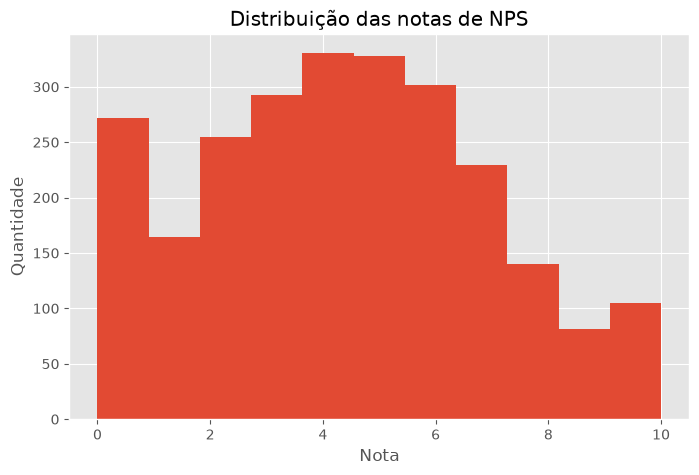

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

df['nps_score'].hist(bins=11)

plt.title("Distribuição das notas de NPS")
plt.xlabel("Nota")
plt.ylabel("Quantidade")
plt.show()

Quantidade de cada categoria

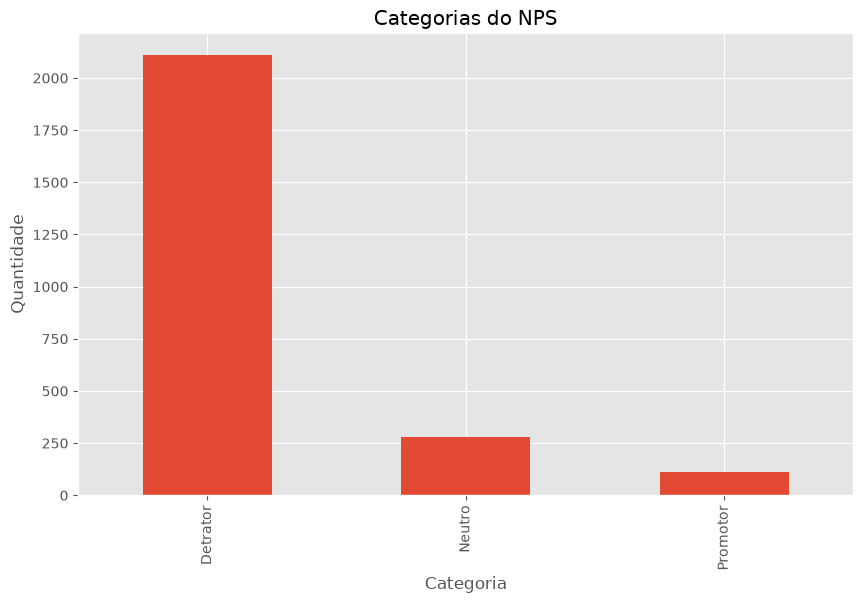

In [12]:
df['categoria_nps'].value_counts().plot(
    kind='bar'
)

plt.title("Categorias do NPS")
plt.xlabel("Categoria")
plt.ylabel("Quantidade")

plt.show()

Correlação

In [13]:
correlacao = df.corr(numeric_only=True)

correlacao['nps_score'].sort_values(ascending=False)

nps_score                    1.000000
repeat_purchase_30d          0.570324
csat_internal_score          0.563952
order_value                  0.036990
delivery_attempts            0.027680
discount_value               0.025104
payment_installments         0.023718
customer_id                  0.015162
order_id                     0.015162
items_quantity               0.011468
delivery_time_days           0.000925
customer_tenure_months      -0.009711
customer_age                -0.009936
freight_value               -0.041087
resolution_time_days        -0.191392
customer_service_contacts   -0.350845
complaints_count            -0.496800
delivery_delay_days         -0.597260
Name: nps_score, dtype: float64

ANALISE EXPLORATORIA DOS DADOS, RESPOSTA DAS PERGUNTAS

1. Quais fatores parecem mais críticos para a satisfação?

Pela correlação com o NPS, os fatores que mais influenciam a satisfação são:

In [14]:
correlacao_nps = (
    correlacao['nps_score']
    .drop('nps_score')
    .sort_values(key=abs, ascending=False)
)

tabela_correlacao = correlacao_nps.reset_index()
tabela_correlacao.columns = ['Variável', 'Correlação com NPS']

# Manter apenas as correlações mais relevantes
tabela_correlacao = tabela_correlacao[
    tabela_correlacao['Correlação com NPS'].abs() >= 0.15
].copy()

# Arredondar valores
tabela_correlacao['Correlação com NPS'] = tabela_correlacao['Correlação com NPS'].round(3)

# Criar interpretação
interpretacoes = {
    'delivery_delay_days': 'Quanto maior o atraso na entrega, menor tende a ser o NPS.',
    'repeat_purchase_30d': 'Clientes que realizam nova compra tendem a apresentar maior NPS.',
    'csat_internal_score': 'Maior satisfação interna está associada a notas mais altas de NPS.',
    'complaints_count': 'Quanto maior o número de reclamações, menor tende a ser o NPS.',
    'customer_service_contacts': 'Clientes que precisam contatar mais vezes o atendimento tendem a avaliar pior a empresa.',
    'resolution_time_days': 'Maior tempo para resolver problemas está relacionado a menor satisfação.'
}

tabela_correlacao['Interpretação'] = (
    tabela_correlacao['Variável'].map(interpretacoes)
)

tabela_correlacao

,Variável,Correlação com NPS,Interpretação
0,delivery_delay_days,-0.597,"Quanto maior o atraso na entrega, menor tende a ser o NPS."
1,repeat_purchase_30d,0.570,Clientes que realizam nova compra tendem a apresentar maior NPS.
2,csat_internal_score,0.564,Maior satisfação interna está associada a notas mais altas de NPS.
3,complaints_count,-0.497,"Quanto maior o número de reclamações, menor tende a ser o NPS."
4,customer_service_contacts,-0.351,Clientes que precisam contatar mais vezes o atendimento tendem a avaliar pior a empresa.
5,resolution_time_days,-0.191,Maior tempo para resolver problemas está relacionado a menor satisfação.


Conclusão: o principal fator de satisfação é a experiência de entrega. Atrasos, reclamações e necessidade de contato com o suporte têm impacto direto na percepção do cliente.

2. O que mais gera detratores?

Os dados indicam que os detratores estão relacionados principalmente a:

Atraso nas entregas (delivery_delay_days).
Maior número de reclamações (complaints_count).
Necessidade de vários contatos com o atendimento (customer_service_contacts).
Maior tempo para resolução de problemas (resolution_time_days).

Esses fatores sugerem que clientes enfrentam dificuldades durante ou após a compra, o que reduz significativamente sua satisfação.

3. Existe algum "ponto de ruptura" na experiência do cliente?

Sim.

O principal ponto de ruptura identificado é o atraso na entrega.

A variável delivery_delay_days apresentou a maior correlação negativa com o NPS (-0,597), indicando que atrasos comprometem fortemente a experiência do cliente. Após esse problema, aumentam também as reclamações e os contatos com o atendimento, agravando ainda mais a percepção negativa.

4. Que tipo de cliente tende a ter NPS mais alto ou mais baixo?
Clientes com maior NPS
Realizam recompra (repeat_purchase_30d).
Possuem maior satisfação interna (csat_internal_score).
Têm poucas ou nenhuma reclamação.
Recebem os pedidos dentro do prazo.
Precisam de pouco ou nenhum contato com o suporte.
Clientes com menor NPS
Sofrem atrasos na entrega.
Registram diversas reclamações.
Precisam entrar em contato várias vezes com o atendimento.
Esperam mais tempo para ter seus problemas resolvidos.